# Analyze Xenium Data with Squidpy

Following the official tutorial: https://squidpy.readthedocs.io/en/stable/notebooks/tutorials/tutorial_xenium.html

**Dataset**: 10x Xenium Human Lung Cancer (2 FOV)

### Sections
1. Install dependencies
2. Download & extract the dataset
3. Load data and convert to Zarr
4. Extract AnnData table
5. Quality control metrics
6. Filter, normalize, cluster
7. Visualize UMAP and spatial layout
8. Spatial neighborhood graph
9. Centrality scores
10. Co-occurrence probability
11. Neighborhood enrichment
12. Moran's I spatial autocorrelation
13. Overlay on morphology image


## 1. Install dependencies

> **Important**: After running this cell, go to **Runtime > Restart runtime**, then continue from Step 2.
>
> `zarr<3` is required — spatialdata is not yet compatible with zarr v3.


In [1]:
!pip install -q squidpy spatialdata spatialdata-io spatialdata-plot scanpy seaborn leidenalg  ome-zarr
print('Done. Now go to Runtime > Restart runtime, then run the rest of the notebook.')


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.3/192.3 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.8/97.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 33.0 MB/s eta 

## 2. Download and extract the dataset

This downloads the **Xenium Human Lung Cancer 2 FOV** bundle (~8 GB) directly into Colab.
Run once - skip if you already have the `Xenium/` folder.


In [1]:
import os

if not os.path.exists('Xenium'):
    print('Downloading dataset (~8 GB)...')
    !curl -O https://cf.10xgenomics.com/samples/xenium/2.0.0/Xenium_V1_human_Lung_2fov/Xenium_V1_human_Lung_2fov_outs.zip
    print('Unzipping...')
    !unzip -q Xenium_V1_human_Lung_2fov_outs.zip -d Xenium
    print('Done!')
else:
    print('Xenium/ folder already exists, skipping download.')

print('\nContents of Xenium/:')
print(os.listdir('Xenium'))


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  265M  100  265M    0     0   187M      0  0:00:01  0:00:01 --:--:--  187M
Unzipping...
Done!

Contents of Xenium/:
['transcripts.parquet', 'analysis.zarr.zip', 'nucleus_boundaries.parquet', 'cell_feature_matrix.zarr.zip', 'experiment.xenium', 'analysis.tar.gz', 'gene_panel.json', 'nucleus_boundaries.csv.gz', 'cell_feature_matrix.tar.gz', 'transcripts.zarr.zip', 'cells.zarr.zip', 'morphology_focus', 'cells.parquet', 'cell_feature_matrix.h5', 'metrics_summary.csv', 'cells.csv.gz', 'aux_outputs.tar.gz', 'cell_boundaries.csv.gz', 'morphology.ome.tif', 'analysis_summary.html', 'cell_boundaries.parquet', 'transcripts.csv.gz']


## 3. Imports


In [2]:
import spatialdata as sd
from spatialdata_io import xenium

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq

print(f'squidpy      : {sq.__version__}')
print(f'scanpy       : {sc.__version__}')
print(f'spatialdata  : {sd.__version__}')


squidpy      : 1.8.1
scanpy       : 1.12.1
spatialdata  : 0.7.2


/tmp/ipykernel_7078/1633005096.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f'scanpy       : {sc.__version__}')


## 4. Load data and convert to Zarr

Parse the Xenium output bundle using `spatialdata-io` and write it to Zarr format.
Run once - skip the write step if `Xenium.zarr` already exists.


In [3]:
xenium_path = './Xenium'
zarr_path   = './Xenium.zarr'

if not os.path.exists(zarr_path):
    print('Parsing Xenium data...')
    # cells_as_circles=True keeps current behavior and silences DeprecationWarning
    sdata = xenium(xenium_path, cells_as_circles=True)
    print('Writing to Zarr...')
    sdata.write(zarr_path)
    print('Zarr store written.')
else:
    print('Zarr store already exists, skipping conversion.')


Parsing Xenium data...


/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


WARNING  The `feature_key` column feature_name is categorical with unknown categories. Please ensure the categories
         are known before calling `PointsModel.parse()` to avoid significant performance implications due to the   
         need for dask to compute the categories. If you did not use PointsModel.parse() explicitly in your code   
         (e.g. this message is coming from a reader in `spatialdata_io`), please report this finding.              
Writing to Zarr...
Zarr store written.


In [4]:
# From now on, read directly from the Zarr store
sdata = sd.read_zarr(zarr_path)
sdata


SpatialData object, with associated Zarr store: /content/Xenium.zarr
├── Images
│     └── 'morphology_focus': DataTree[cyx] (1, 3553, 5791), (1, 1776, 2895), (1, 888, 1447), (1, 444, 723), (1, 222, 361)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (3553, 5791), (1776, 2895), (888, 1447), (444, 723), (222, 361)
│     └── 'nucleus_labels': DataTree[yx] (3553, 5791), (1776, 2895), (888, 1447), (444, 723), (222, 361)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 11) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (11898, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (11898, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (11898, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (11898, 289)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), cell_circles (Shapes), nucleu

## 5. Extract the AnnData table

The `AnnData` object contains the gene expression count matrix and cell metadata.
`obsm['spatial']` holds the (x, y) centroid of each cell.


In [5]:
adata = sdata.tables['table']
adata


AnnData object with n_obs × n_vars = 11898 × 289
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [6]:
adata.obs


,cell_id,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,region,z_level,nucleus_count,cell_labels
0,aaafiiei-1,67,0,0,0,0,67,139.126411,29.125782,cell_circles,5.0,1.0,1
1,aaanbaof-1,69,0,0,0,0,69,154.434381,31.519064,cell_circles,5.0,1.0,2
2,aabdiein-1,63,0,0,0,0,63,148.247974,25.693907,cell_circles,5.0,1.0,3
3,aabfemmf-1,78,0,0,0,0,78,120.251098,33.551095,cell_circles,5.0,1.0,4
4,aacflbgf-1,19,0,0,0,0,19,31.067501,8.128125,cell_circles,5.0,1.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11893,oigahkgf-1,52,0,0,0,0,52,32.918907,21.268595,cell_circles,5.0,1.0,11894
11894,oigeilci-1,38,0,0,0,0,38,33.415626,21.313751,cell_circles,5.0,1.0,11895
11895,oigjdpec-1,30,0,0,0,0,30,27.319532,16.752969,cell_circles,5.0,1.0,11896
11896,oigkmfoa-1,49,0,0,0,0,49,32.196407,16.030469,cell_circles,5.0,1.0,11897


In [7]:
adata.obsm['spatial']


array([[ 37.24629974, 667.76745605],
       [ 44.10276031, 701.72283936],
       [ 40.73135757, 684.13360596],
       ...,
       [683.22277832, 359.48660278],
       [685.75463867, 364.47491455],
       [679.56671143, 362.38049316]])

## 6. Quality control metrics

Calculate QC metrics and check the fraction of control probe / codeword counts (should be << 1%).


In [8]:
sc.pp.calculate_qc_metrics(adata, percent_top=(10, 20, 50, 150), inplace=True)

cprobes = (
    adata.obs['control_probe_counts'].sum() / adata.obs['total_counts'].sum() * 100
)
cwords = (
    adata.obs['control_codeword_counts'].sum() / adata.obs['total_counts'].sum() * 100
)
print(f'Negative DNA probe count % : {cprobes}')
print(f'Negative decoding count %  : {cwords}')


Negative DNA probe count % : 0.002462100746426876
Negative decoding count %  : 0.005334551617258232


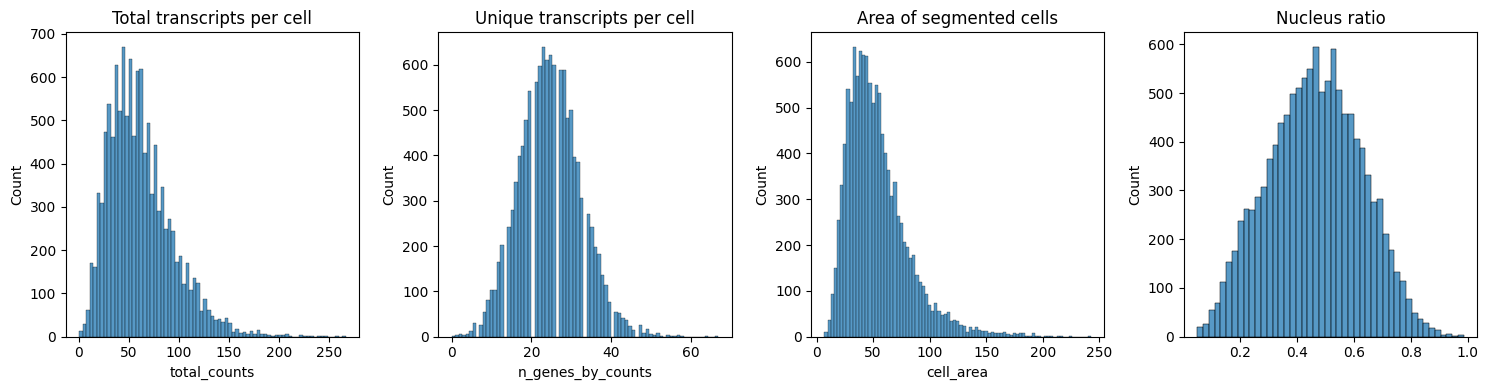

In [9]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4))

axs[0].set_title('Total transcripts per cell')
sns.histplot(adata.obs['total_counts'], kde=False, ax=axs[0])

axs[1].set_title('Unique transcripts per cell')
sns.histplot(adata.obs['n_genes_by_counts'], kde=False, ax=axs[1])

axs[2].set_title('Area of segmented cells')
sns.histplot(adata.obs['cell_area'], kde=False, ax=axs[2])

axs[3].set_title('Nucleus ratio')
sns.histplot(adata.obs['nucleus_area'] / adata.obs['cell_area'], kde=False, ax=axs[3])

plt.tight_layout()
plt.show()


## 7. Filter, normalize, and cluster

Filter low-quality cells and genes, then run the standard scanpy preprocessing pipeline.


In [10]:
sc.pp.filter_cells(adata, min_counts=10)
sc.pp.filter_genes(adata, min_cells=5)


In [11]:
adata.layers['counts'] = adata.X.copy()
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata)


/tmp/ipykernel_7078/506322169.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata)


## 8. Visualize UMAP and spatial layout


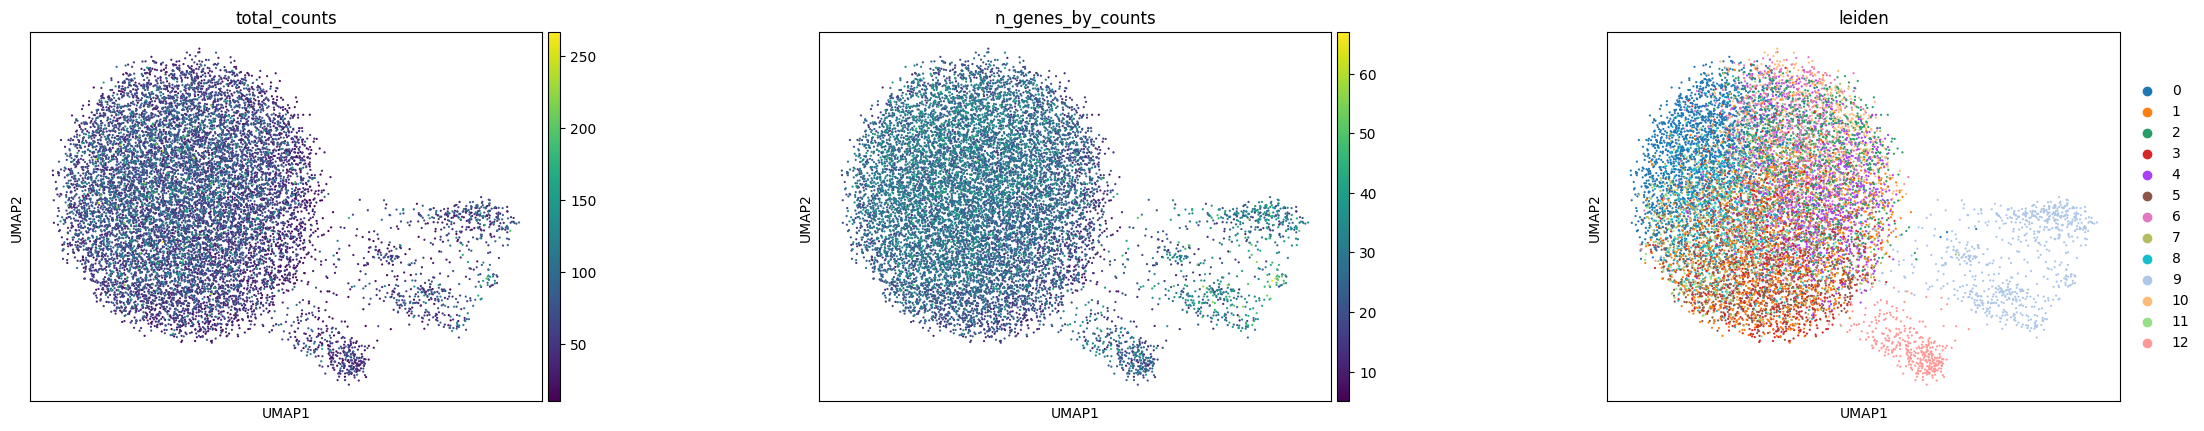

In [12]:
sc.pl.umap(
    adata,
    color=['total_counts', 'n_genes_by_counts', 'leiden'],
    wspace=0.4,
)


/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


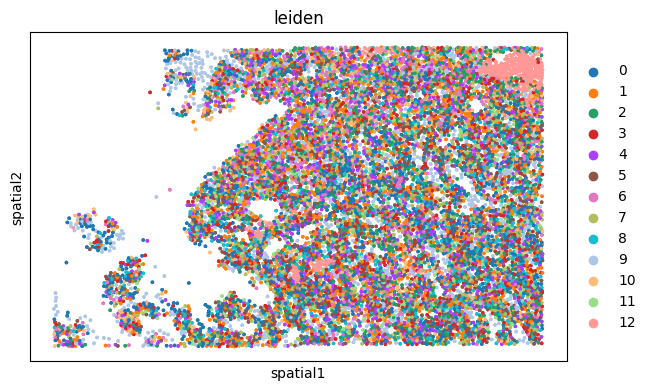

In [13]:
sq.pl.spatial_scatter(
    adata,
    library_id='spatial',
    shape=None,
    color=['leiden'],
    wspace=0.4,
)


## 9. Build spatial neighborhood graph

Compute a connectivity matrix from spatial coordinates using Delaunay triangulation.
All spatial statistics below rely on this graph.


In [14]:
sq.gr.spatial_neighbors(adata, coord_type='generic', delaunay=True)


INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


## 10. Centrality scores

Scores calculated per cluster:
- **Closeness centrality**: how close a cluster is to all others
- **Clustering coefficient**: how densely clustered the neighborhood is
- **Degree centrality**: fraction of non-group nodes connected to the group


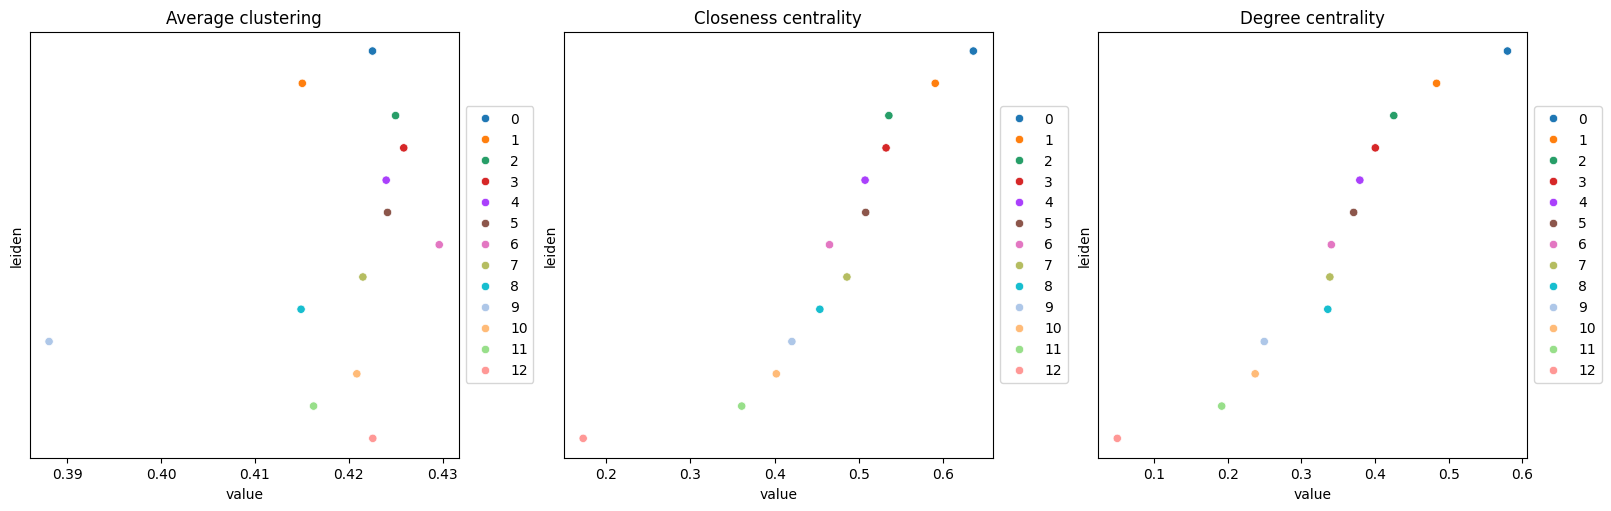

In [15]:
sq.gr.centrality_scores(adata, cluster_key='leiden')
sq.pl.centrality_scores(adata, cluster_key='leiden', figsize=(16, 5))


## 11. Co-occurrence probability

Measures how often clusters co-occur across increasing spatial radii.

> **Warning**: This step is slow (~15-20 min). Reduce `fraction` to `0.1` for a quick test.


In [16]:
# Subsample for speed
sdata.tables['subsample'] = sc.pp.subsample(adata, fraction=0.5, copy=True)
adata_subsample = sdata.tables['subsample']
print(f'Subsample: {adata_subsample.n_obs} cells')


Subsample: 5910 cells


/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


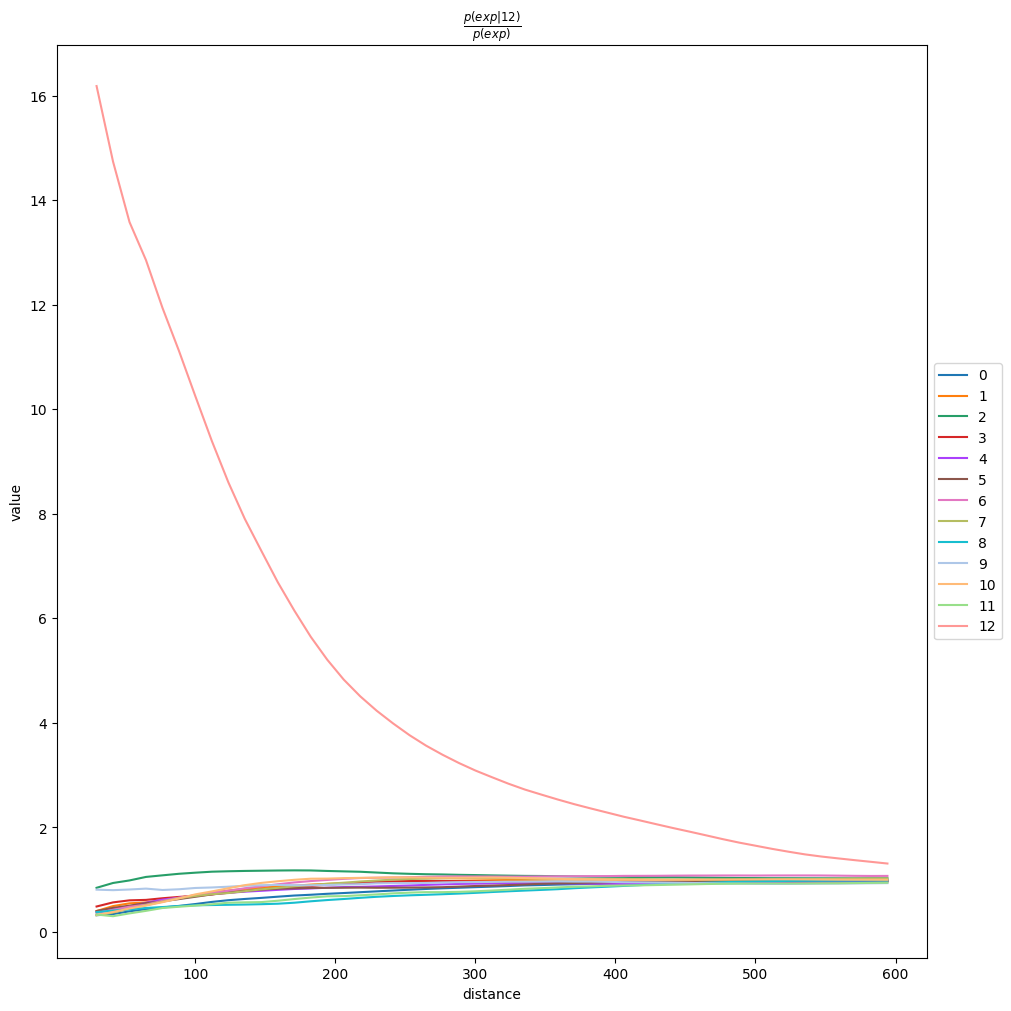

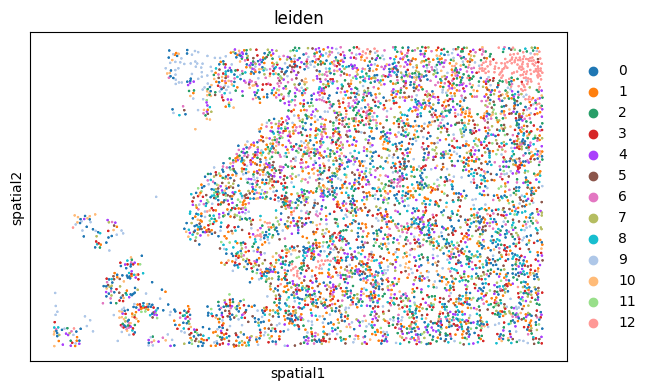

In [17]:
sq.gr.co_occurrence(
    adata_subsample,
    cluster_key='leiden',
)
sq.pl.co_occurrence(
    adata_subsample,
    cluster_key='leiden',
    clusters='12',
    figsize=(10, 10),
)
sq.pl.spatial_scatter(
    adata_subsample,
    color='leiden',
    shape=None,
    size=2,
)


## 12. Neighborhood enrichment

Calculates a z-score for cluster co-localization based on proximity in the connectivity graph.
Observed events are compared against permutations.


In [18]:
sq.gr.nhood_enrichment(adata, cluster_key='leiden')


  0%|          | 0/1000 [00:00<?, ?/s]

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


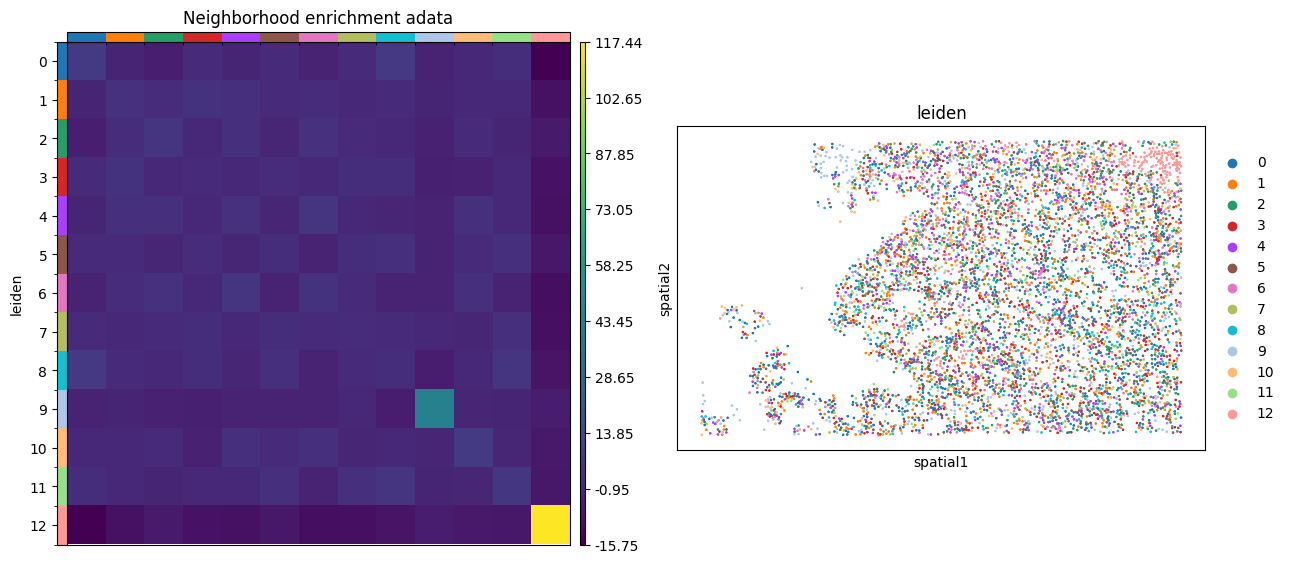

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(13, 7))
sq.pl.nhood_enrichment(
    adata,
    cluster_key='leiden',
    figsize=(8, 8),
    title='Neighborhood enrichment adata',
    ax=ax[0],
)
sq.pl.spatial_scatter(adata_subsample, color='leiden', shape=None, size=2, ax=ax[1])
plt.tight_layout()
plt.show()


## 13. Moran's I spatial autocorrelation

Evaluates whether gene expression shows a spatially clustered, dispersed or random pattern.
High Moran's I = gene is spatially clustered in tissue patches.

> **Warning**: Slow (~6 min with n_perms=100). Reduce `n_perms` for a quick test.


In [20]:
sq.gr.spatial_neighbors(adata_subsample, coord_type='generic', delaunay=True)
sq.gr.spatial_autocorr(
    adata_subsample,
    mode='moran',
    n_perms=100,
    n_jobs=1,
)
adata_subsample.uns['moranI'].head(10)


INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


  0%|          | 0/100 [00:00<?, ?/s]

,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh
IGFBP3,0.386782,0.0,0.000057,0.0,0.009901,0.000083,0.0,0.0,0.022756
GJA5,0.367843,0.0,0.000057,0.0,0.009901,0.000059,0.0,0.0,0.022756
CXCL13,0.277089,0.0,0.000057,0.0,0.009901,0.000069,0.0,0.0,0.022756
PLA2G7,0.232207,0.0,0.000057,0.0,0.009901,0.000056,0.0,0.0,0.022756
GPX2,0.223969,0.0,0.000057,0.0,0.009901,0.000065,0.0,0.0,0.022756
ANPEP,0.219542,0.0,0.000057,0.0,0.009901,0.000056,0.0,0.0,0.022756
MYH11,0.207796,0.0,0.000057,0.0,0.009901,0.000048,0.0,0.0,0.022756
LTBP2,0.195293,0.0,0.000057,0.0,0.009901,0.000045,0.0,0.0,0.022756
DIRAS3,0.193210,0.0,0.000057,0.0,0.009901,0.000043,0.0,0.0,0.022756
AGR3,0.165852,0.0,0.000057,0.0,0.009901,0.000038,0.0,0.0,0.022756


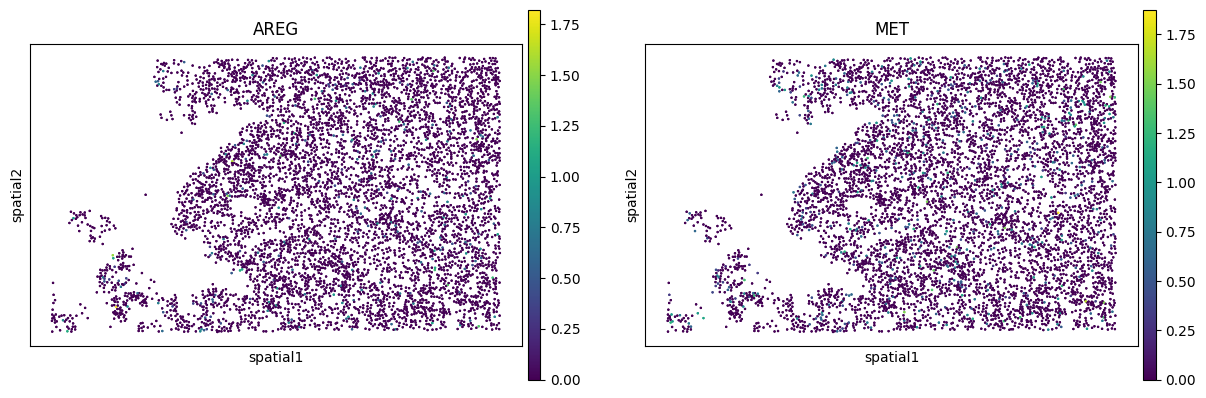

In [21]:
sq.pl.spatial_scatter(
    adata_subsample,
    library_id='spatial',
    color=['AREG', 'MET'],
    shape=None,
    size=2,
    img=False,
)


## 14. Overlay gene expression on the morphology image

Uses `spatialdata-plot` to render the morphology image with gene expression overlaid.

> **Note**: This requires the morphology image to be present in `sdata`.
> If `sdata` shows no Images section, it means the morphology image was not
> written to Zarr (can happen with zarr v3). Make sure you are using `zarr<3`
> and delete `Xenium.zarr` to regenerate it.


In [22]:
import spatialdata_plot

# Check images are available
print('Images in sdata:', list(sdata.images.keys()))


Images in sdata: ['morphology_focus']


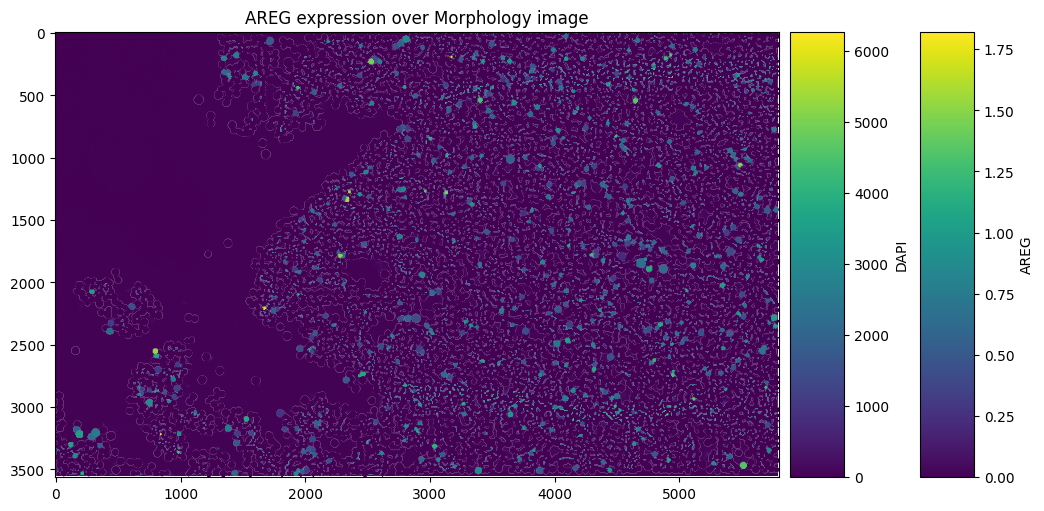

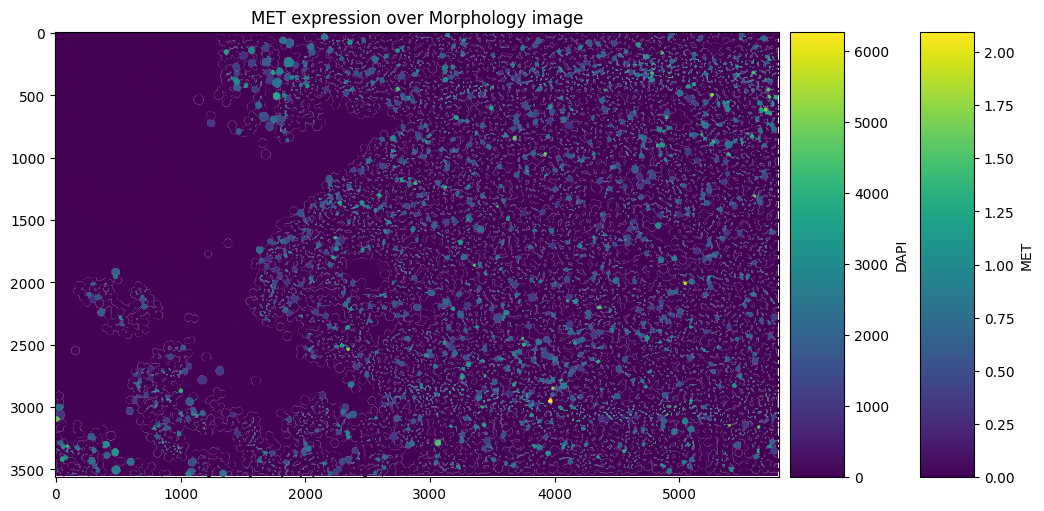

In [23]:
gene_name = ['AREG', 'MET']
for name in gene_name:
    sdata.pl.render_images('morphology_focus').pl.render_shapes(
        'cell_circles',
        color=name,
        table_name='table',
        use_raw=False,
    ).pl.show(
        title=f'{name} expression over Morphology image',
        coordinate_systems='global',
        figsize=(10, 5),
    )


## 15. (Optional) Interactive visualization with napari

Only works with a local display. Won't work in headless Colab.

```python
from napari_spatialdata import Interactive
Interactive(sdata)
```


---
## Done!

You have completed the full Squidpy Xenium tutorial.
See the [Squidpy API docs](https://squidpy.readthedocs.io/en/stable/api.html) for more analyses.
